In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
import seaborn as sns
from sklearn.model_selection import cross_val_score

california_housing = fetch_california_housing()
x, y = california_housing.data, california_housing.target

california_housing_df = pd.DataFrame(data=x, columns=california_housing.feature_names)
california_housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [100]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [101]:
lg_model = LinearRegression()
lg_model.fit(x_train_scaled, y_train)

y_train_pred = lg_model.predict(x_train_scaled)
y_pred = lg_model.predict(x_test_scaled)

print(f'Train r2 score: {round(r2_score(y_train, y_train_pred), 4)}')
print(f'Test r2 score: {round(r2_score(y_test, y_pred), 4)}')

scores_lr = cross_val_score(lg_model, x, y, cv=5, scoring='r2')
print("Linear CV R² Mean (میانگین):", np.mean(scores_lr).round(4))
print("Linear CV R² Std (انحراف استاندارد):", np.std(scores_lr).round(4))

Train r2 score: 0.6126
Test r2 score: 0.5758
Linear CV R² Mean (میانگین): 0.553
Linear CV R² Std (انحراف استاندارد): 0.0617


In [103]:
lg_coef_df = pd.DataFrame({
    'feature': california_housing.feature_names,
    'coef': lg_model.coef_,
}).sort_values(by='coef', ascending=False, ignore_index=True)
lg_coef_df

,feature,coef
0,MedInc,0.854383
1,AveBedrms,0.339259
2,HouseAge,0.122546
3,Population,-0.002308
4,AveOccup,-0.040829
5,AveRooms,-0.294410
6,Longitude,-0.869842
7,Latitude,-0.896929


In [104]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_model.fit(x_train_scaled, y_train)
y_train_pred = elastic_model.predict(x_train_scaled)
y_test_pred = elastic_model.predict(x_test_scaled)

print(f'Train elastic r2 score: {round(r2_score(y_train, y_train_pred), 4)}')
print(f'Test elastic r2 score: {round(r2_score(y_test, y_test_pred), 4)}')

coef_df = pd.DataFrame({
    'feature': california_housing.feature_names,
    'lg_coef': lg_model.coef_,
    'elastic_coef': elastic_model.coef_,
})
coef_df

Train elastic r2 score: 0.5308
Test elastic r2 score: 0.5148


,feature,lg_coef,elastic_coef
0,MedInc,0.854383,0.713818
1,HouseAge,0.122546,0.137288
2,AveRooms,-0.294410,-0.000000
3,AveBedrms,0.339259,0.000000
4,Population,-0.002308,0.000000
5,AveOccup,-0.040829,-0.000000
6,Latitude,-0.896929,-0.175737
7,Longitude,-0.869842,-0.133250


In [108]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
x_trains_scaled_pca = pca.fit_transform(x_train_scaled)
x_test_scaled_pca = pca.transform(x_test_scaled)

lg_model.fit(x_trains_scaled_pca, y_train)
y_train_pred = lg_model.predict(x_trains_scaled_pca)
y_test_pred = lg_model.predict(x_test_scaled_pca)

In [89]:
print(f'Train pca r2 score: {round(r2_score(y_train, y_train_pred), 4)}')
print(f'Test pca r2 score: {round(r2_score(y_test, y_test_pred), 4)}')

Train pca r2 score: 0.4567
Test pca r2 score: 0.4329


In [109]:
heart_disease_df = pd.read_csv('heart_cleveland_upload.csv')
x, y = heart_disease_df[heart_disease_df.columns.difference(['condition'])], heart_disease_df['condition']

In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=4, random_state=42)
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print('Random forest accuracy:', round(accuracy_score(y_train, y_train_pred), 4))
print('Random forest accuracy:', round(accuracy_score(y_test, y_test_pred), 4))

Random forest accuracy: 0.9179
Random forest accuracy: 0.7889


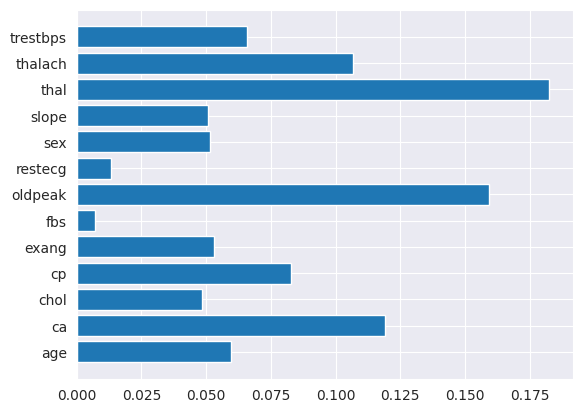

In [92]:
plt.barh(X_train.columns, rf.feature_importances_)
plt.show();

In [93]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm, end="\n\n")

print(classification_report(y_test, y_test_pred), end="\n\n")
print(f'TN (True Negative): {cm[0][0]}')
print(f'TP (True Positive): {cm[1][1]}')
print(f'FP (False Positive): {cm[0][1]}')
print(f'FN (False Negative): {cm[1][0]}')

Confusion Matrix:
 [[39  9]
 [10 32]]

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        48
           1       0.78      0.76      0.77        42

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90


TN (True Negative): 39
TP (True Positive): 32
FP (False Positive): 9
FN (False Negative): 10


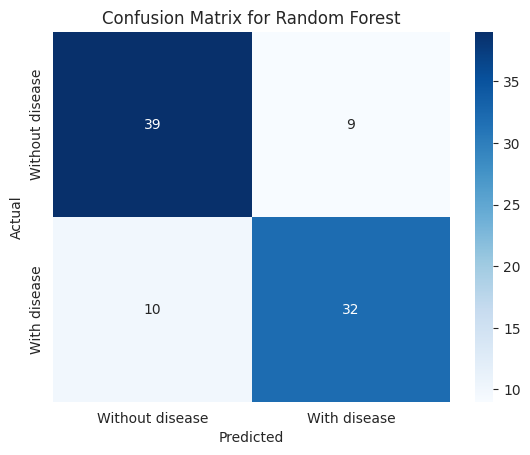

In [94]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Without disease', 'With disease'], yticklabels=['Without disease', 'With disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show();